In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
# import importlib
# import TweezerArrayRegionsExtraction
# importlib.reload(TweezerArrayRegionsExtraction)
# from  TweezerArrayRegionsExtraction import  *

## import

Focal pixelpitch: [3.10546875, 3.10546875]
The input gaussian light beam waist: 6240um
The init gaussian phase is random generated.
2103


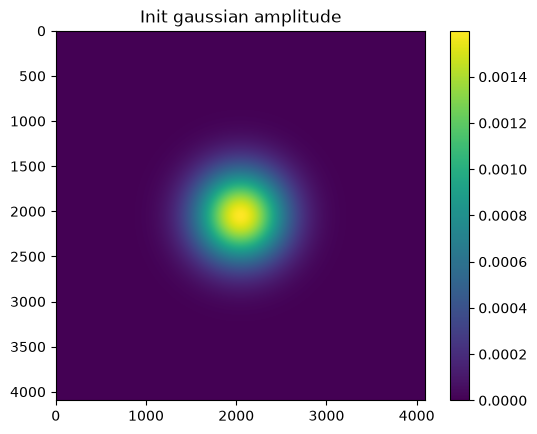

In [3]:


import WGS
import numpy as np
import scipy as sp
import torch
import torch.fft as fft
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image
import os
import time
import json
from Aberration import Zernike
from SLMGeneration import SLM_class
import json
import torch
# from BlinkSLM import BlinkSLM
from avt import VimbaCamera

import IMGpy
import slmpy

from TweezerArrayRegionsExtraction import *


slm = slmpy.SLMdisplay(monitor=1,isImageLock = True)

SLM = SLM_class()

SLM.image_init()  #
LUT=224
SLM_screen_Correct=lambda SLM_screen:IMGpy.SLM_screen_Correct(SLM_screen,LUT=LUT,correctionImgPath='CAL_LSH0804730_785nm.bmp')
print(2103)

In [3]:
%pip install --upgrade pip setuptools wheel
%pip install numpy scipy matplotlib pillow scikit-learn wxPython==4.2.5 "vmbpy[numpy]" opencv-python zernike ipykernel jupyter

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


focal pixelpitch: [3.10546875, 3.10546875]
array spacing: [150, 150]
spacing pixels: [48, 48]
arraysize: [8, 8]
(array([1880, 1880, 1880, 1880, 1880, 1880, 1880, 1928, 1928, 1928, 1928,
       1928, 1928, 1928, 1928, 1976, 1976, 1976, 1976, 1976, 1976, 1976,
       1976, 2024, 2024, 2024, 2024, 2024, 2024, 2072, 2072, 2072, 2072,
       2072, 2072, 2120, 2120, 2120, 2120, 2120, 2120, 2120, 2120, 2168,
       2168, 2168, 2168, 2168, 2168, 2168, 2168, 2216, 2216, 2216, 2216,
       2216, 2216, 2216, 2216]), array([1880, 1976, 2024, 2072, 2120, 2168, 2216, 1880, 1928, 1976, 2024,
       2072, 2120, 2168, 2216, 1880, 1928, 1976, 2024, 2072, 2120, 2168,
       2216, 1880, 1928, 1976, 2120, 2168, 2216, 1880, 1928, 1976, 2120,
       2168, 2216, 1880, 1928, 1976, 2024, 2072, 2120, 2168, 2216, 1880,
       1928, 1976, 2024, 2072, 2120, 2168, 2216, 1880, 1928, 1976, 2024,
       2072, 2120, 2168, 2216]))


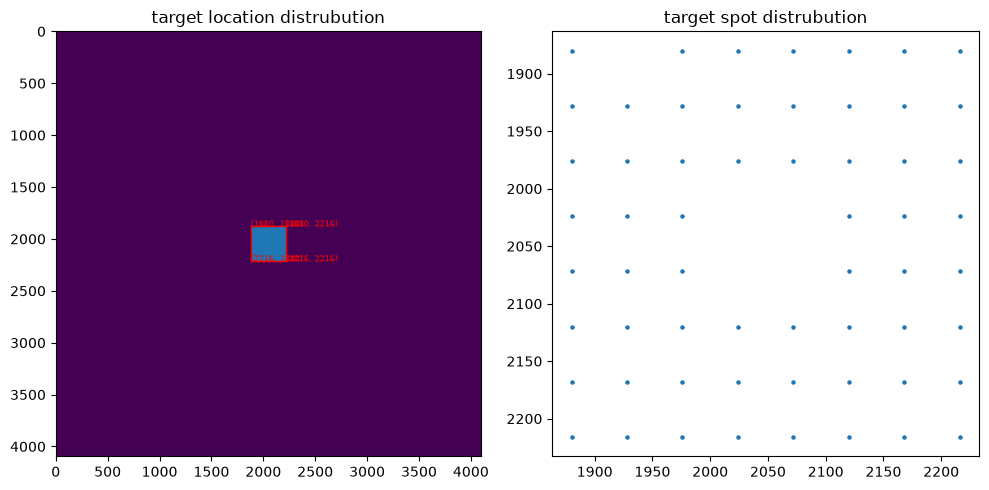

You have generated the target with [0, 0]um distance relative to the center.
目标光镊数： 59


In [4]:

targetAmp=SLM.target_generate("Rec",  Plot = True,exception=[[0,1],[3,3],[3,4],[4,3],[4,4]])
print("目标光镊数：", np.count_nonzero(targetAmp))

In [5]:
# dpath='抖动测试/气浮/'
# if not os.path.exists(dpath):
#     os.mkdir(dpath)
# with VimbaCamera() as camera:
#     for k in range(200,500):
#         print(k,end=' ')
#         # image = camera.capture(150)[1520:1620,2170:2270]
#         # image = camera.capture(150)[1500:1600,1400:1500]
#         image = camera.capture(50)[1500:1600,950:1050]
#
#         if k==0:
#             plt.imshow(image)
#             plt.show()
#             print(image.max())
#         Image.fromarray(image).save(dpath+f'{k}.bmp')
#         # break

## init phase

C:\Users\37828\AppData\Local\Temp\ipykernel_63056\998081959.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  SLM_Phase=WGS.WGS_phase_generate(torch.tensor(SLM.initGaussianAmp), torch.tensor(RandomPhase), torch.from_numpy(targetAmp), Loop=20, threshold=0.005, Plot=True)


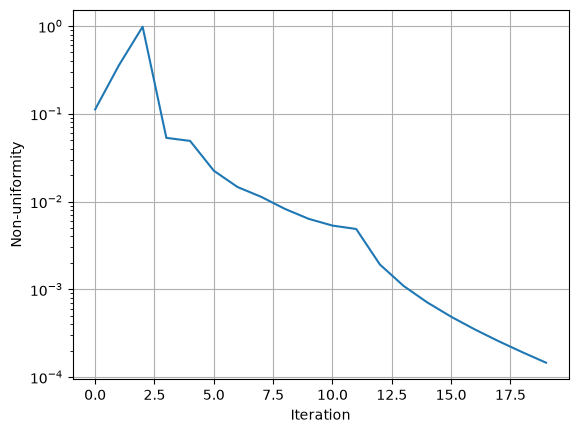

In [6]:
# 调用 WGS_phase_generate 函数
import WGS
input_shape = (4096, 4096)  # 输入振幅分布的尺寸

RandomPhase = torch.rand(input_shape, dtype=torch.float32) * 2 * np.pi - np.pi

SLM_Phase=WGS.WGS_phase_generate(torch.tensor(SLM.initGaussianAmp), torch.tensor(RandomPhase), torch.from_numpy(targetAmp), Loop=20, threshold=0.005, Plot=True)
SLM_screen=SLM.phase_to_screen(SLM_Phase.cpu().clone().numpy())

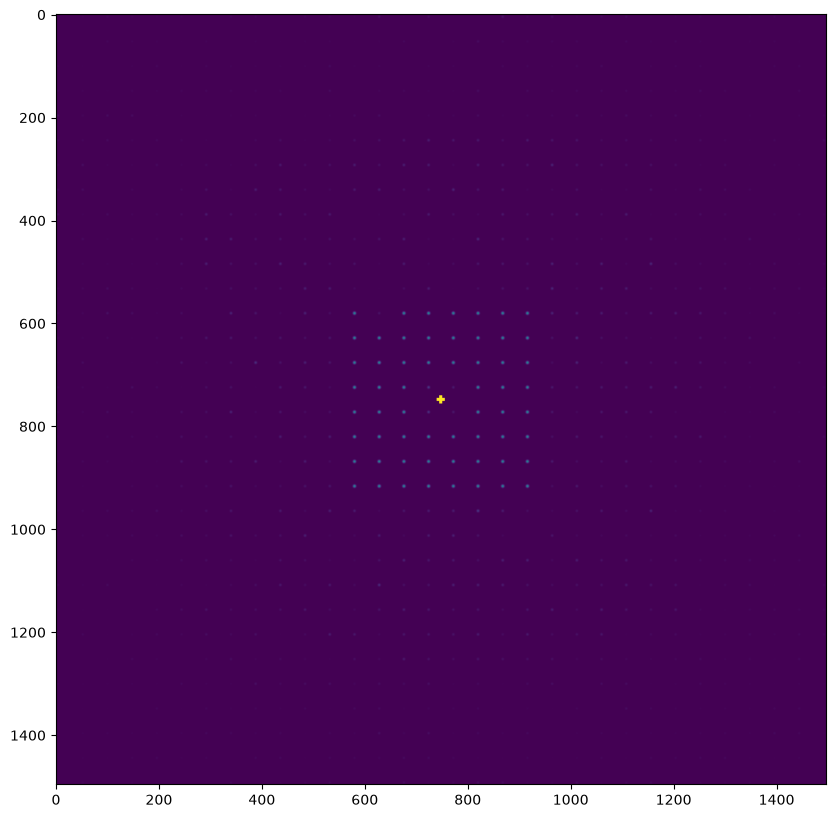

In [7]:
#模拟输出
SLM_screen=SLM.phase_to_screen(SLM_Phase.cpu().clone().numpy())
fftAmp,fftPhase = SLM.phase_to_fftField(SLM_Phase.cpu())
centerX=len(fftAmp)//2
centerY=len(fftAmp[0])//2
fftAmp[centerX-8:centerX+8,centerY-3:centerY+3]=2*np.max(fftAmp)
fftAmp[centerX-3:centerX+3,centerY-8:centerY+8]=np.max(fftAmp)#显示中心
plt.figure(figsize=(10,10))
edgeCutOff=1300
plt.imshow(fftAmp[edgeCutOff:-edgeCutOff,edgeCutOff:-edgeCutOff])
plt.show()
# blinkslm.slm_lib.Delete_SDK()

## write init phase to slm

In [13]:
fresnel_lens=SLM.fresnel_lens_phase_generate(0,SLM.SLMRes[0]//2,SLM.SLMRes[1]//2)[0]
SLM_screen_shift=SLM_screen+fresnel_lens
SLM_screen_Corrected=SLM_screen_Correct(SLM_screen_shift)

np.save('SLM_img0.npy',SLM_screen_Corrected)
slm.updateArray(SLM_screen_Corrected)


## 进行均匀性优化，读取IDS

(3036, 4024)


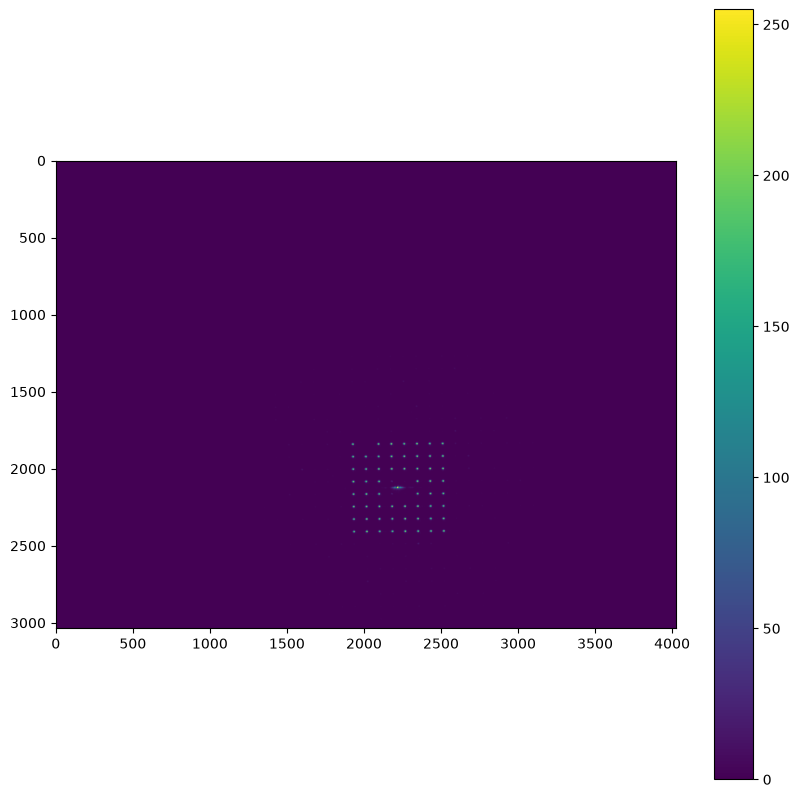

255


In [51]:

etime=23
with VimbaCamera() as camera:
    image = camera.capture(etime)
print(image.shape)
plt.figure(figsize=(10,10))

plt.imshow(image)
plt.colorbar()
plt.show()
print(image.max())
#旋转/翻转至与上方模拟图片一致

In [17]:
#new by gpt
    
def non_uniformity_show(non_uniformity):
    non_uniformity = np.asarray(non_uniformity, dtype=float)

    if len(non_uniformity) == 0:
        print("目前还没有均匀性数据")
        return

    min_index = int(np.argmin(non_uniformity))
    min_value = float(non_uniformity[min_index])

    plt.figure()
    plt.plot(non_uniformity, marker="o")
    plt.plot(min_index, min_value, "o")
    plt.annotate(
        f"Minimum: {min_value:.4f}",
        xy=(min_index, min_value),
        xytext=(min_index + 0.3, min_value),
        arrowprops=dict(arrowstyle="->"),
    )
    plt.title("Tweezer Uniformity Optimization")
    plt.xlabel("Measurement / iteration")
    plt.ylabel("std / mean")
    plt.grid()
    plt.show()

In [20]:
def non_uniformity_show(non_uniformity):
    non_uniformity = np.array(non_uniformity)
    min_index = np.argmin(non_uniformity)
    min_value = np.min(non_uniformity)
    min_index=0
    plt.plot(non_uniformity)
    plt.plot(min_index,min_value,'.')
    plt.annotate(f'Minimum: {min_value:.3f}', xy=(min_index, min_value),
                xytext=(min_index + 1, min_value),
                arrowprops=dict(facecolor='black', arrowstyle='->'))
    plt.title('Tweezer Uniformity Optimization')
    plt.xlabel('Number of iterations')
    plt.ylabel('Non uniformity')
    plt.show()
    

# 适用于4f系统优化  
def camera_intensity_array_generate(intensity):
    intensity = np.array(intensity)
    intensity_2d_array = intensity.reshape(9,11)
    intensity_flip = np.transpose(intensity_2d_array)
    intensity_flip = np.flip(intensity_flip, axis=1)
    camera_intensity_array = intensity_flip.flatten()

    return camera_intensity_array

[367 386 104] [482 504 193]


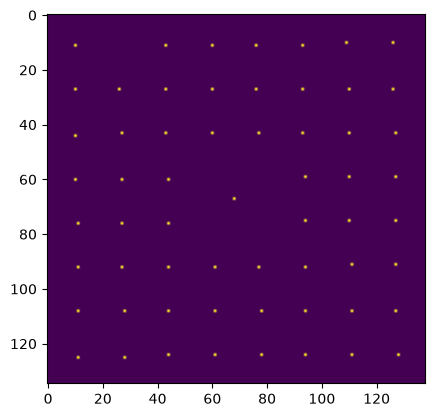

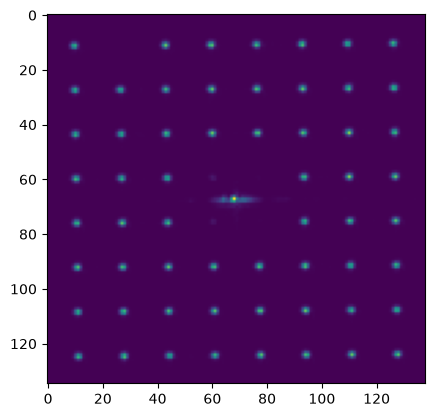

寻找到 59 个极值点
值=120.0000, 坐标=(1840, 1930)
值=147.0000, 坐标=(1840, 2095)
值=138.0000, 坐标=(1840, 2180)
值=131.0000, 坐标=(1840, 2260)
值=116.0000, 坐标=(1920, 1930)
值=134.0000, 坐标=(1840, 2345)
值=105.0000, 坐标=(1835, 2425)
值=106.0000, 坐标=(1920, 2010)
值=127.0000, 坐标=(1835, 2510)
值=130.0000, 坐标=(1920, 2095)
值=146.0000, 坐标=(1920, 2180)
值=138.0000, 坐标=(1920, 2260)
值=145.0000, 坐标=(1920, 2345)
值=120.0000, 坐标=(2005, 1930)
值=109.0000, 坐标=(2000, 2015)
值=130.0000, 坐标=(1920, 2430)
值=128.0000, 坐标=(2000, 2095)
值=117.0000, 坐标=(1920, 2510)
值=149.0000, 坐标=(2000, 2180)
值=135.0000, 坐标=(2000, 2265)
值=139.0000, 坐标=(2000, 2345)
值=132.0000, 坐标=(2085, 1930)
值=159.0000, 坐标=(2000, 2430)
值=120.0000, 坐标=(2085, 2015)
值=128.0000, 坐标=(2000, 2515)
值=104.0000, 坐标=(2085, 2100)
值=124.0000, 坐标=(2080, 2350)
值=122.0000, 坐标=(2165, 1935)
值=193.0000, 坐标=(2120, 2220)
值=156.0000, 坐标=(2080, 2430)
值=143.0000, 坐标=(2165, 2015)
值=145.0000, 坐标=(2080, 2515)
值=131.0000, 坐标=(2165, 2100)
值=119.0000, 坐标=(2160, 2350)
值=139.0000, 坐标=(2245, 1935)
值=132.00

In [29]:

def find_local_maxima(arr, threshold=80, array_size=(6, 6),n_spots=None):#寻找极值点
    pool=5
    minDistance=1
    arr0=arr
    arr=arr[:len(arr)//pool*pool,:len(arr[0])//pool*pool]   #池化
    arr=arr.reshape((len(arr)//pool,pool,len(arr[0])//pool,pool)).astype(int).mean(axis=1).mean(axis=2)
    # plt.imshow(arr)
    # plt.show()    

    mask = np.ones_like(arr, dtype=bool)    #对比四周寻找极值点
    mask[:-1]=mask[:-1]*(arr[:-1]>=arr[1:])
    mask[1:]=mask[1:]*(arr[1:]>=arr[:-1])
    mask[:,:-1]=mask[:,:-1]*(arr[:,:-1]>=arr[:,1:])
    mask[:,1:]=mask[:,1:]*(arr[:,1:]>=arr[:,:-1])
    mask=mask*(arr>=threshold)*(arr<=255)    #去除噪点与过曝点

    mask[[0, -1], :] = False    #去除边界
    mask[:, [0, -1]] = False

    rows, cols = np.nonzero(mask)
    values = arr[rows, cols]
    maxima_data=np.array([rows,cols,values])
    order_value = np.argsort(-values)[:n_spots]
    maxima_data=maxima_data[:,order_value]

    order = np.argsort(5*maxima_data[0]+maxima_data[1])
    maxima_data=maxima_data[:,order]
    maxima_data=maxima_data.astype(int)

    print(maxima_data.min(axis=1),maxima_data.max(axis=1))
    plt.imshow(mask[maxima_data[0].min()-10:maxima_data[0].max()+10,maxima_data[1].min()-10:maxima_data[1].max()+10])
    plt.show()
    plt.imshow(arr[maxima_data[0].min()-10:maxima_data[0].max()+10,maxima_data[1].min()-10:maxima_data[1].max()+10])
    plt.show()

    print('寻找到',len(maxima_data[0]),'个极值点')
    maxima_data[:2]=maxima_data[:2]*pool
    return maxima_data

def fit_matrix(rows, cols):
    pass

# plt.imshow(image)
# plt.show()
max_points = find_local_maxima(image,array_size=SLM.arraysize,n_spots=np.count_nonzero(targetAmp))
for row, col,value in max_points.T:
    print(f"值={value:.4f}, 坐标=({row}, {col})")


In [30]:
#聚类提取行列信息
from sklearn.cluster import KMeans


# scikit-learn 的 KMeans 需要二维输入，这里把数组 reshape
kmeans = KMeans(n_clusters=SLM.arraysize[0], n_init=10, random_state=0).fit(max_points[0].reshape(-1, 1))
row_center=np.sort(kmeans.cluster_centers_.flatten()).astype(int)
print('行中心：', row_center)
print('检查间距：', row_center[1:]-row_center[:-1])
kmeans = KMeans(n_clusters=SLM.arraysize[1], n_init=10, random_state=0).fit(max_points[1].reshape(-1, 1))
col_center=np.sort(kmeans.cluster_centers_.flatten()).astype(int)
print('行中心：', col_center)
print('检查间距：', col_center[1:]-col_center[:-1])

行中心： [1838 1920 2000 2087 2162 2243 2325 2406]
检查间距： [82 80 87 75 81 82 81]
行中心： [1932 2015 2097 2187 2265 2348 2431 2514]
检查间距： [83 82 90 78 83 83 83]


[[1813 1863 1907 1957]
 [1813 1863 1990 2040]
 [1813 1863 2073 2123]
 [1813 1863 2156 2206]
 [1813 1863 2240 2290]
 [1813 1863 2323 2373]
 [1813 1863 2406 2456]
 [1813 1863 2489 2539]
 [1894 1944 1907 1957]
 [1894 1944 1990 2040]
 [1894 1944 2073 2123]
 [1894 1944 2156 2206]
 [1894 1944 2240 2290]
 [1894 1944 2323 2373]
 [1894 1944 2406 2456]
 [1894 1944 2489 2539]
 [1975 2025 1907 1957]
 [1975 2025 1990 2040]
 [1975 2025 2073 2123]
 [1975 2025 2156 2206]
 [1975 2025 2240 2290]
 [1975 2025 2323 2373]
 [1975 2025 2406 2456]
 [1975 2025 2489 2539]
 [2056 2106 1907 1957]
 [2056 2106 1990 2040]
 [2056 2106 2073 2123]
 [2056 2106 2156 2206]
 [2056 2106 2240 2290]
 [2056 2106 2323 2373]
 [2056 2106 2406 2456]
 [2056 2106 2489 2539]
 [2138 2188 1907 1957]
 [2138 2188 1990 2040]
 [2138 2188 2073 2123]
 [2138 2188 2156 2206]
 [2138 2188 2240 2290]
 [2138 2188 2323 2373]
 [2138 2188 2406 2456]
 [2138 2188 2489 2539]
 [2219 2269 1907 1957]
 [2219 2269 1990 2040]
 [2219 2269 2073 2123]
 [2219 2269

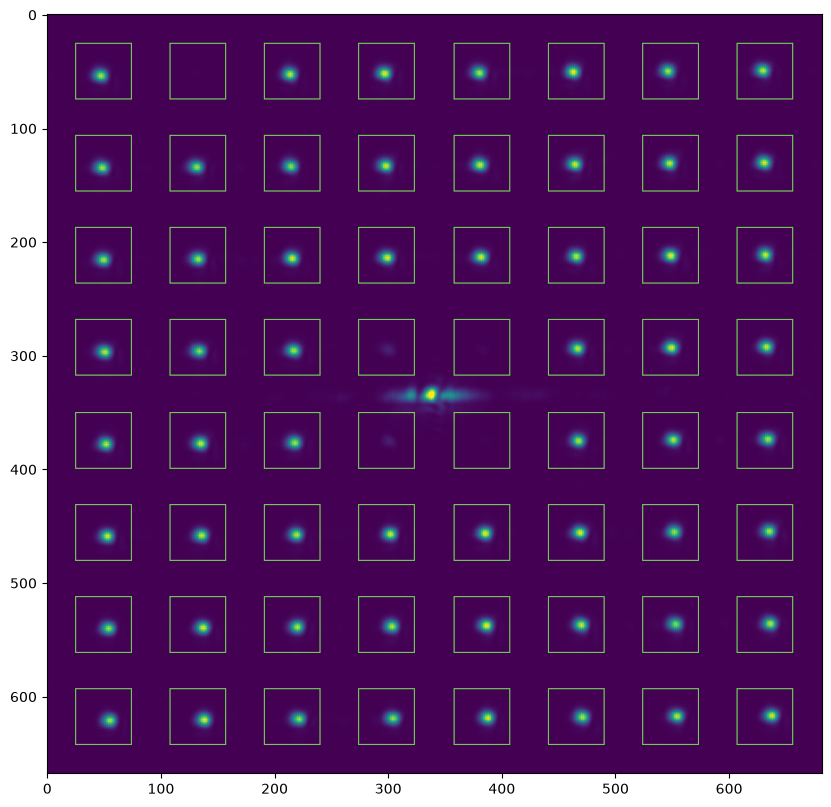

In [43]:


x1=row_center[0]
x2=row_center[-1]
y1=col_center[0]
y2=col_center[-1]
region_size=50
points = generate_points([x1, y1],[x1, y2],[x2, y1],[x2, y2],SLM.arraysize)
regions = generate_regions(points, [region_size,region_size])       
print(regions)
# 找到点
aoi = generate_aoi(regions, image, 200)
new_img = image+aoi
plt.figure(figsize=(10,10))
plt.imshow(new_img[x1-region_size:x2+region_size,y1-region_size:y2+region_size])


In [44]:
print(regions.shape)

(64, 4)


8.9336
0.0204
9.22
9.7372
9.2604
9.7436
8.9084
9.2704
8.8712
8.9636
8.5972
9.6104
9.716
9.7168
9.2972
9.702
8.8796
8.932
9.5216
9.736
9.5828
9.1692
9.898
9.4232
9.4616
8.6652
8.9904
0.9296
0.1268
9.2448
9.6624
9.1204
9.0116
9.438
9.0304
0.9776
0.1484
8.9984
8.8612
9.15
9.2336
9.0392
8.8556
9.1372
9.716
9.722
8.8488
9.1152
8.5112
9.21
8.958
8.9608
9.7804
9.3752
8.8404
9.442
8.6672
9.6324
8.6448
8.684
9.4904
9.1848
8.9916
9.3296
[[1813 1863 1907 1957]
 [1813 1863 2073 2123]
 [1813 1863 2156 2206]
 [1813 1863 2240 2290]
 [1813 1863 2323 2373]
 [1813 1863 2406 2456]
 [1813 1863 2489 2539]
 [1894 1944 1907 1957]
 [1894 1944 1990 2040]
 [1894 1944 2073 2123]
 [1894 1944 2156 2206]
 [1894 1944 2240 2290]
 [1894 1944 2323 2373]
 [1894 1944 2406 2456]
 [1894 1944 2489 2539]
 [1975 2025 1907 1957]
 [1975 2025 1990 2040]
 [1975 2025 2073 2123]
 [1975 2025 2156 2206]
 [1975 2025 2240 2290]
 [1975 2025 2323 2373]
 [1975 2025 2406 2456]
 [1975 2025 2489 2539]
 [2056 2106 1907 1957]
 [2056 2106 1990 

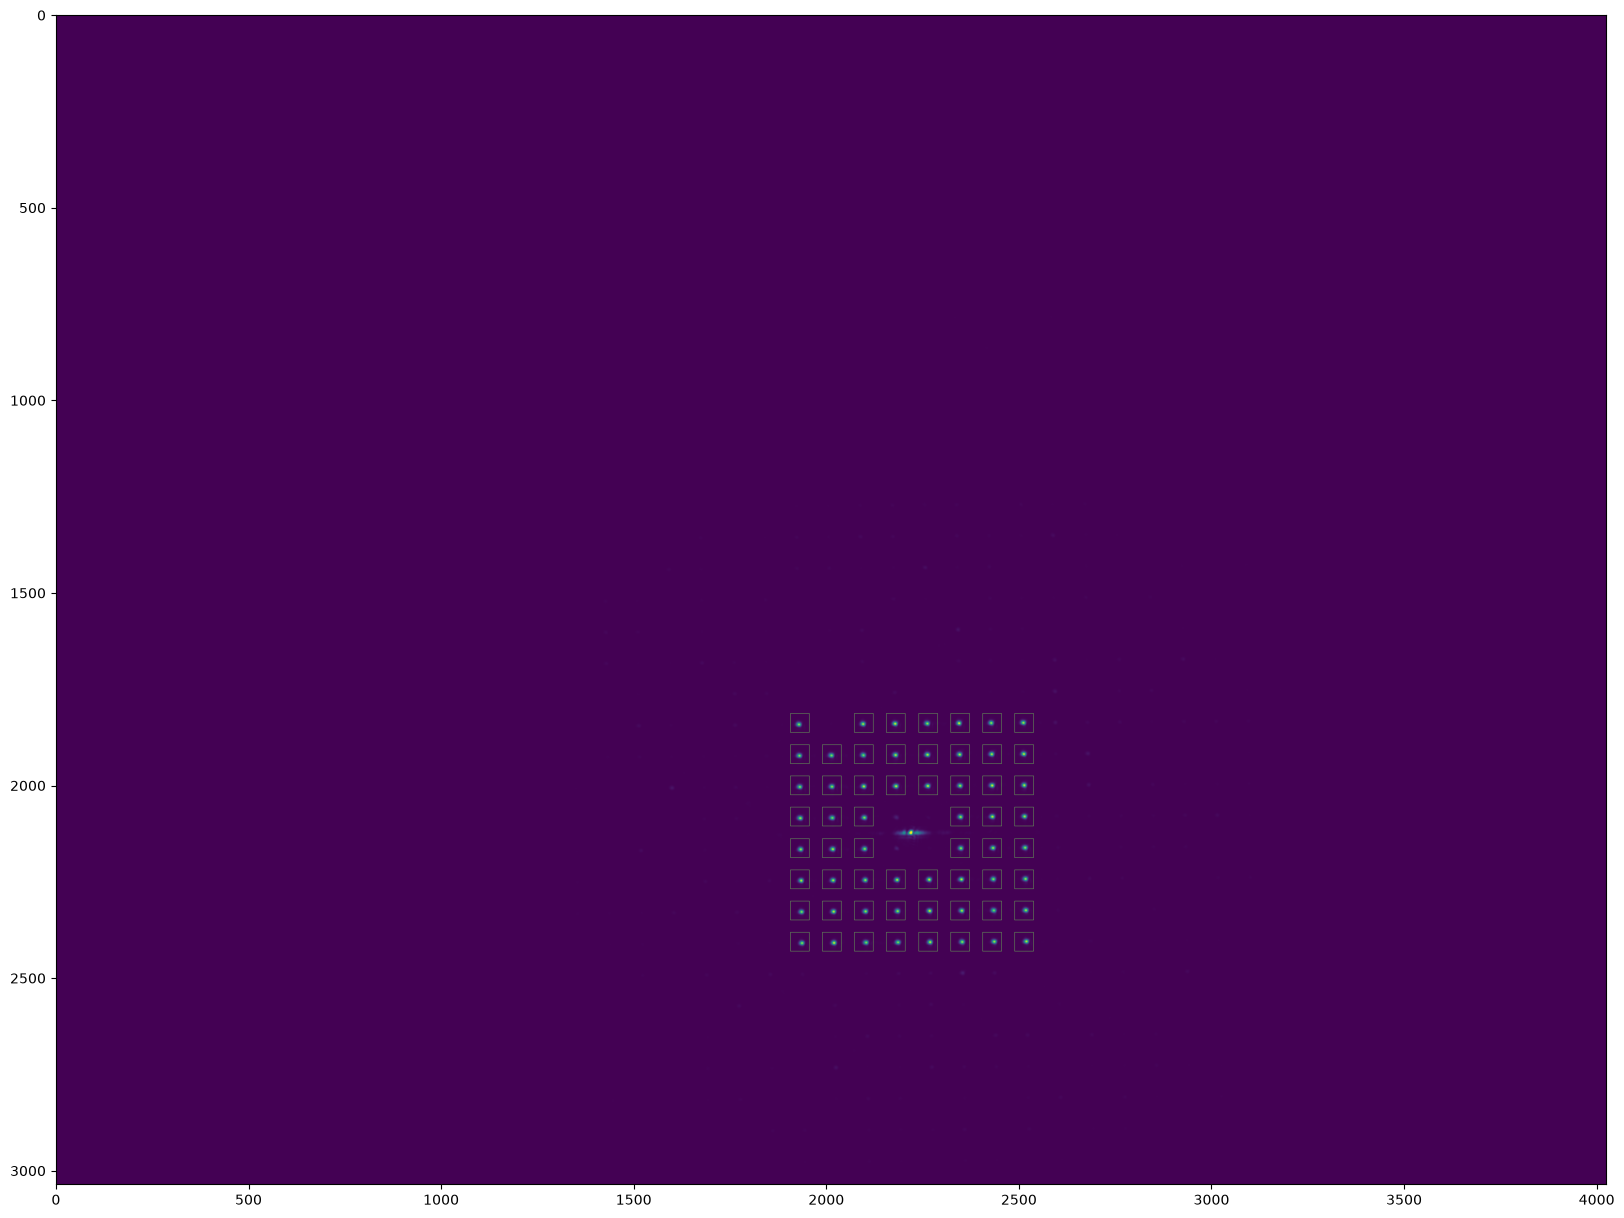

In [47]:
#regions_trans = np.flip(np.transpose(regions.reshape(8,5,4),axes=(1,0,2)),axis=0).reshape(-1,4)

lower_than_thres = lambda x: np.mean(x) < 8.5 #原来是10

x1 = regions[:,0]
x2 = regions[:,1]
y1 = regions[:,2]
y2 = regions[:,3]
dark_ls = []
for i in range(SLM.arraysize[0]*SLM.arraysize[1]):
    print(image[x1[i]:x2[i],y1[i]:y2[i]].mean())
    if lower_than_thres(image[x1[i]:x2[i],y1[i]:y2[i]]):
        dark_ls.append(i)
regions_trans = np.delete(regions, dark_ls, axis=0)

# regions_trans = regions_trans[c]#point select order
aoi = generate_aoi(regions_trans, image, 200)
# print(regions_trans)
plt.figure(figsize=(20,20))
plt.imshow(image+aoi)
print(regions_trans)


# print('max:',rotated_image[1103:1128,1063:1088].max())


In [48]:
regions = regions_trans
##%%
x1 = regions[:,0]
x2 = regions[:,1]
y1 = regions[:,2]
y2 = regions[:,3]
print(regions)
index = 0
non_uniformity = []
intensity_data = [] 
targetAmp_data = []
intensity_list=[]
time_interval = 1

[[1813 1863 1907 1957]
 [1813 1863 2073 2123]
 [1813 1863 2156 2206]
 [1813 1863 2240 2290]
 [1813 1863 2323 2373]
 [1813 1863 2406 2456]
 [1813 1863 2489 2539]
 [1894 1944 1907 1957]
 [1894 1944 1990 2040]
 [1894 1944 2073 2123]
 [1894 1944 2156 2206]
 [1894 1944 2240 2290]
 [1894 1944 2323 2373]
 [1894 1944 2406 2456]
 [1894 1944 2489 2539]
 [1975 2025 1907 1957]
 [1975 2025 1990 2040]
 [1975 2025 2073 2123]
 [1975 2025 2156 2206]
 [1975 2025 2240 2290]
 [1975 2025 2323 2373]
 [1975 2025 2406 2456]
 [1975 2025 2489 2539]
 [2056 2106 1907 1957]
 [2056 2106 1990 2040]
 [2056 2106 2073 2123]
 [2056 2106 2323 2373]
 [2056 2106 2406 2456]
 [2056 2106 2489 2539]
 [2138 2188 1907 1957]
 [2138 2188 1990 2040]
 [2138 2188 2073 2123]
 [2138 2188 2323 2373]
 [2138 2188 2406 2456]
 [2138 2188 2489 2539]
 [2219 2269 1907 1957]
 [2219 2269 1990 2040]
 [2219 2269 2073 2123]
 [2219 2269 2156 2206]
 [2219 2269 2240 2290]
 [2219 2269 2323 2373]
 [2219 2269 2406 2456]
 [2219 2269 2489 2539]
 [2300 2350

1813 1907 131 13588
1813 2073 142 13984
1813 2156 148 14796
1813 2240 137 14092
1813 2323 152 14799
1813 2406 132 13505
1813 2489 138 13986
1894 1907 137 13412
1894 1990 132 13533
1894 2073 123 12888
1894 2156 144 14327
1894 2240 144 14594
1894 2323 147 14737
1894 2406 143 13933
1894 2489 144 14444
1975 1907 130 13282
1975 1990 134 13582
1975 2073 145 14239
1975 2156 140 14654
1975 2240 146 14507
1975 2323 139 13758
1975 2406 151 14903
1975 2489 140 14188
2056 1907 143 14449
2056 1990 126 12976
2056 2073 134 13561
2056 2323 141 14051
2056 2406 143 14454
2056 2489 138 13545
2138 1907 135 13514
2138 1990 138 14222
2138 2073 134 13516
2138 2323 135 13319
2138 2406 136 13480
2138 2489 134 13707
2219 1907 144 14011
2219 1990 138 13528
2219 2073 137 13401
2219 2156 148 13709
2219 2240 149 14469
2219 2323 144 14759
2219 2406 132 13369
2219 2489 135 13742
2300 1907 132 12843
2300 1990 145 13998
2300 2073 134 13225
2300 2156 131 13433
2300 2240 152 14727
2300 2323 140 14101
2300 2406 122 13273


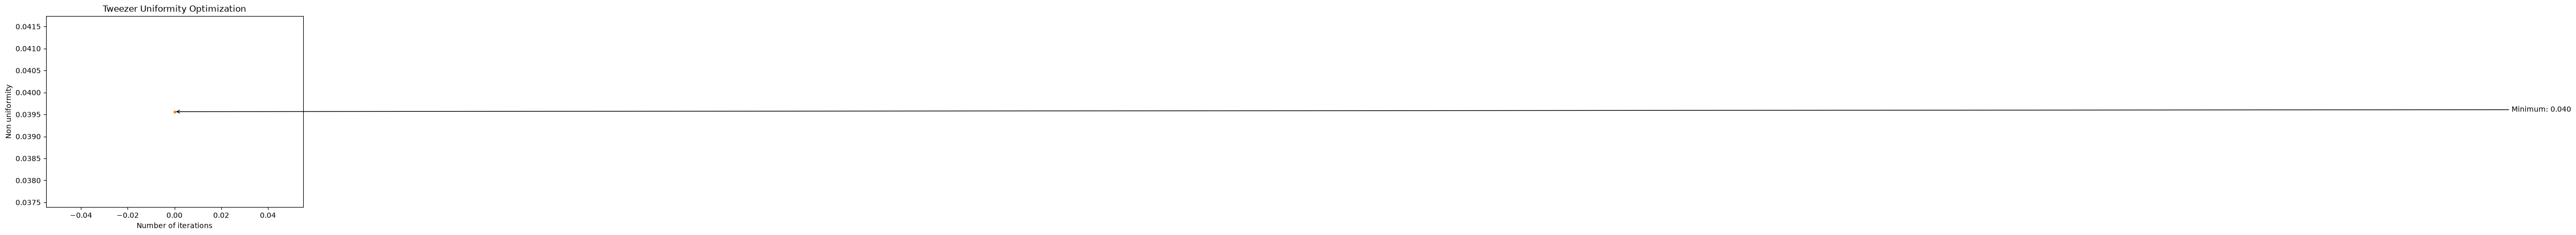

(array([2., 3., 1., 1., 3., 4., 8., 3., 4., 0., 2., 6., 2., 5., 1., 5., 1.,
        2., 5., 1.]),
 array([12843., 12946., 13049., 13152., 13255., 13358., 13461., 13564.,
        13667., 13770., 13873., 13976., 14079., 14182., 14285., 14388.,
        14491., 14594., 14697., 14800., 14903.]),
 <BarContainer object of 20 artists>)

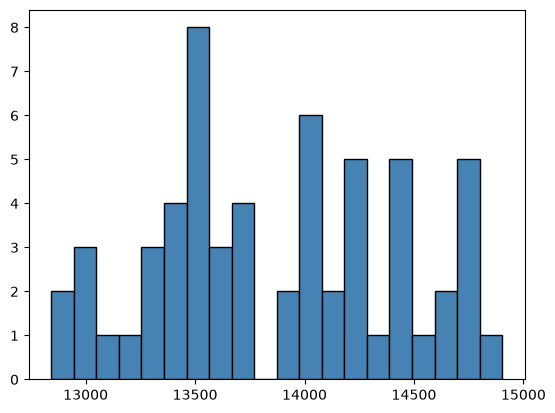

In [49]:

with VimbaCamera() as camera:
    image = camera.capture(etime)

intensity = []
image_ROI = []
for i  in range(len(x1)):
        cur_roi = image[x1[i]:x2[i],y1[i]:y2[i]]
        image_ROI.append(cur_roi)
        print(x1[i],y1[i],cur_roi.max(),cur_roi.sum())
        if cur_roi.max()>250:print('该点过曝！')
        intensity.append(cur_roi.sum())



intensity = np.array(intensity)
camera_intensity = intensity.copy()
print(camera_intensity)
# camera_intensity=np.flip(camera_intensity)
intensity_data.append(camera_intensity)
non_uniformity.append(camera_intensity.std()/camera_intensity.mean())
print(camera_intensity.std()/camera_intensity.mean())
non_uniformity_show(non_uniformity)

plt.hist(x = intensity, # 指定绘图数据
         bins = 20, # 指定直方图中条块的个数
         color = 'steelblue', # 指定直方图的填充色
         edgecolor = 'black' # 指定直方图的边框色
         )


In [50]:
np.save('SLM_img1.npy', SLM_screen)

In [52]:
SLM_screen=np.load('SLM_img1.npy')
SLM_screen_shift=SLM_screen+fresnel_lens
SLM_screen_Corrected=SLM_screen_Correct(SLM_screen_shift)
slm.updateArray(SLM_screen_Corrected)

0 标准差/均值： 0.013238534840516885
相机每个区域总光强: 9506.55402542373 * [1.00205868 0.98010672 0.99270329 0.99127007 0.97015306 0.99840988
 0.98172403 1.00493827 0.98802889 1.00381405 1.00274242 0.99008668
 1.02020406 0.99355797 0.98647075 0.99846905 0.99081644 0.99211817
 1.02757397 0.99586559 1.005267   0.99084931 1.02271548 0.99029049
 0.99137526 1.01618709 0.98326244 1.00720645 1.01951375 0.99778531
 1.0219397  0.99592476 1.00225591 0.99837701 0.97722055 0.99324897
 1.02078918 1.01533899 0.99224309 1.00975732 1.00462928 1.00885005
 0.98799602 0.99425486 0.99936975 0.99459015 0.97879184 1.00920507
 1.00854763 1.00068463 1.01554938 0.99052059 0.98983028 0.99388669
 1.01872482 1.01407013 1.01204521 1.02865875 0.98713477]
Start the new SLM phase generation ...
1 标准差/均值： 0.004370003786391964


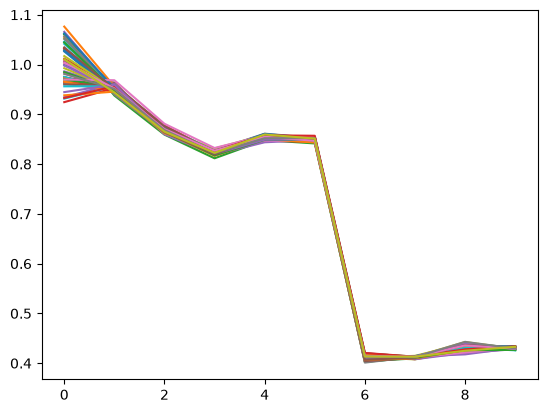

相机每个区域总光强: 9505.310381355932 * [1.00134815 1.00324183 1.00270923 1.00552345 1.00057885 1.00534592
 1.00212404 0.9983301  0.99199812 0.99948735 1.00440566 0.99978981
 0.99251756 0.99393125 1.00105884 0.99898106 0.99991474 1.00539195
 0.99692957 1.00294594 1.00870588 1.0007761  0.99001238 0.99622602
 1.00144021 1.0018413  1.00117062 1.00126268 1.00199911 0.99945448
 0.99541068 1.00244622 1.00088788 0.99789614 0.99464138 0.99942817
 0.99858654 1.00066433 0.99716628 0.99560137 1.00291964 1.00332731
 1.00810753 1.003781   0.99566712 1.00302485 1.00128898 0.99597616
 1.00432675 0.98933513 1.00529332 0.99733066 0.99114991 1.00791685
 0.99606821 1.00176897 0.99700847 0.9977449  1.00579304]
Start the new SLM phase generation ...
2 标准差/均值： 0.004664576592213439


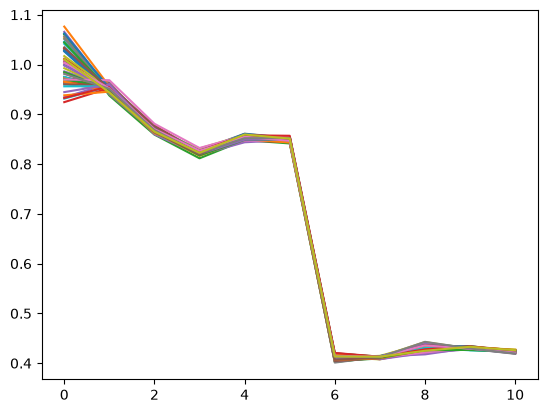

相机每个区域总光强: 9346.503177966102 * [1.00221974 1.0004945  1.00383799 1.00420578 1.0071748  1.00483436
 0.99399474 0.99865557 0.99722456 1.00407204 1.0059444  0.99362696
 0.99814736 1.00046775 1.00480761 1.00204588 0.99179472 1.0035772
 0.99491086 0.99849509 1.00142399 0.99902336 1.00213281 0.99420872
 0.99644887 1.00042763 1.00458694 0.99977899 1.00869944 0.99594066
 1.00195226 1.00155773 1.00403192 0.99800694 0.99834129 0.99580023
 0.99210901 1.00133037 0.99991273 1.00119663 0.99858202 1.00833165
 1.00007322 0.9943224  0.99129988 1.00520214 0.99582029 0.98951446
 1.00896692 1.00022702 0.99978568 0.99832791 0.99957169 1.00573041
 1.00098265 1.00353039 0.99491086 0.99089198 1.00648604]
Start the new SLM phase generation ...
3 标准差/均值： 0.0031864459382239525


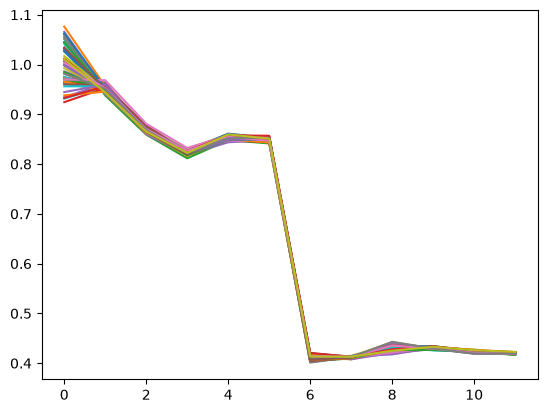

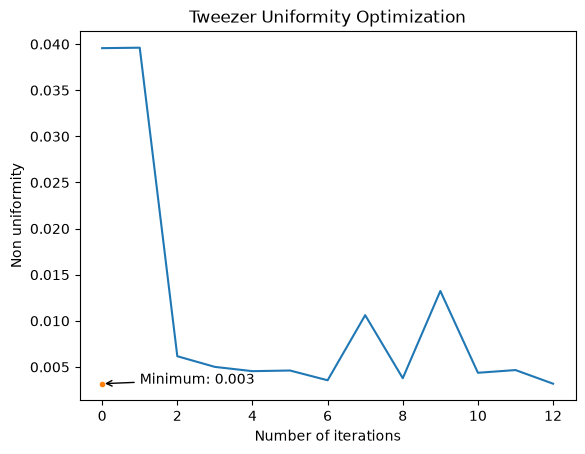

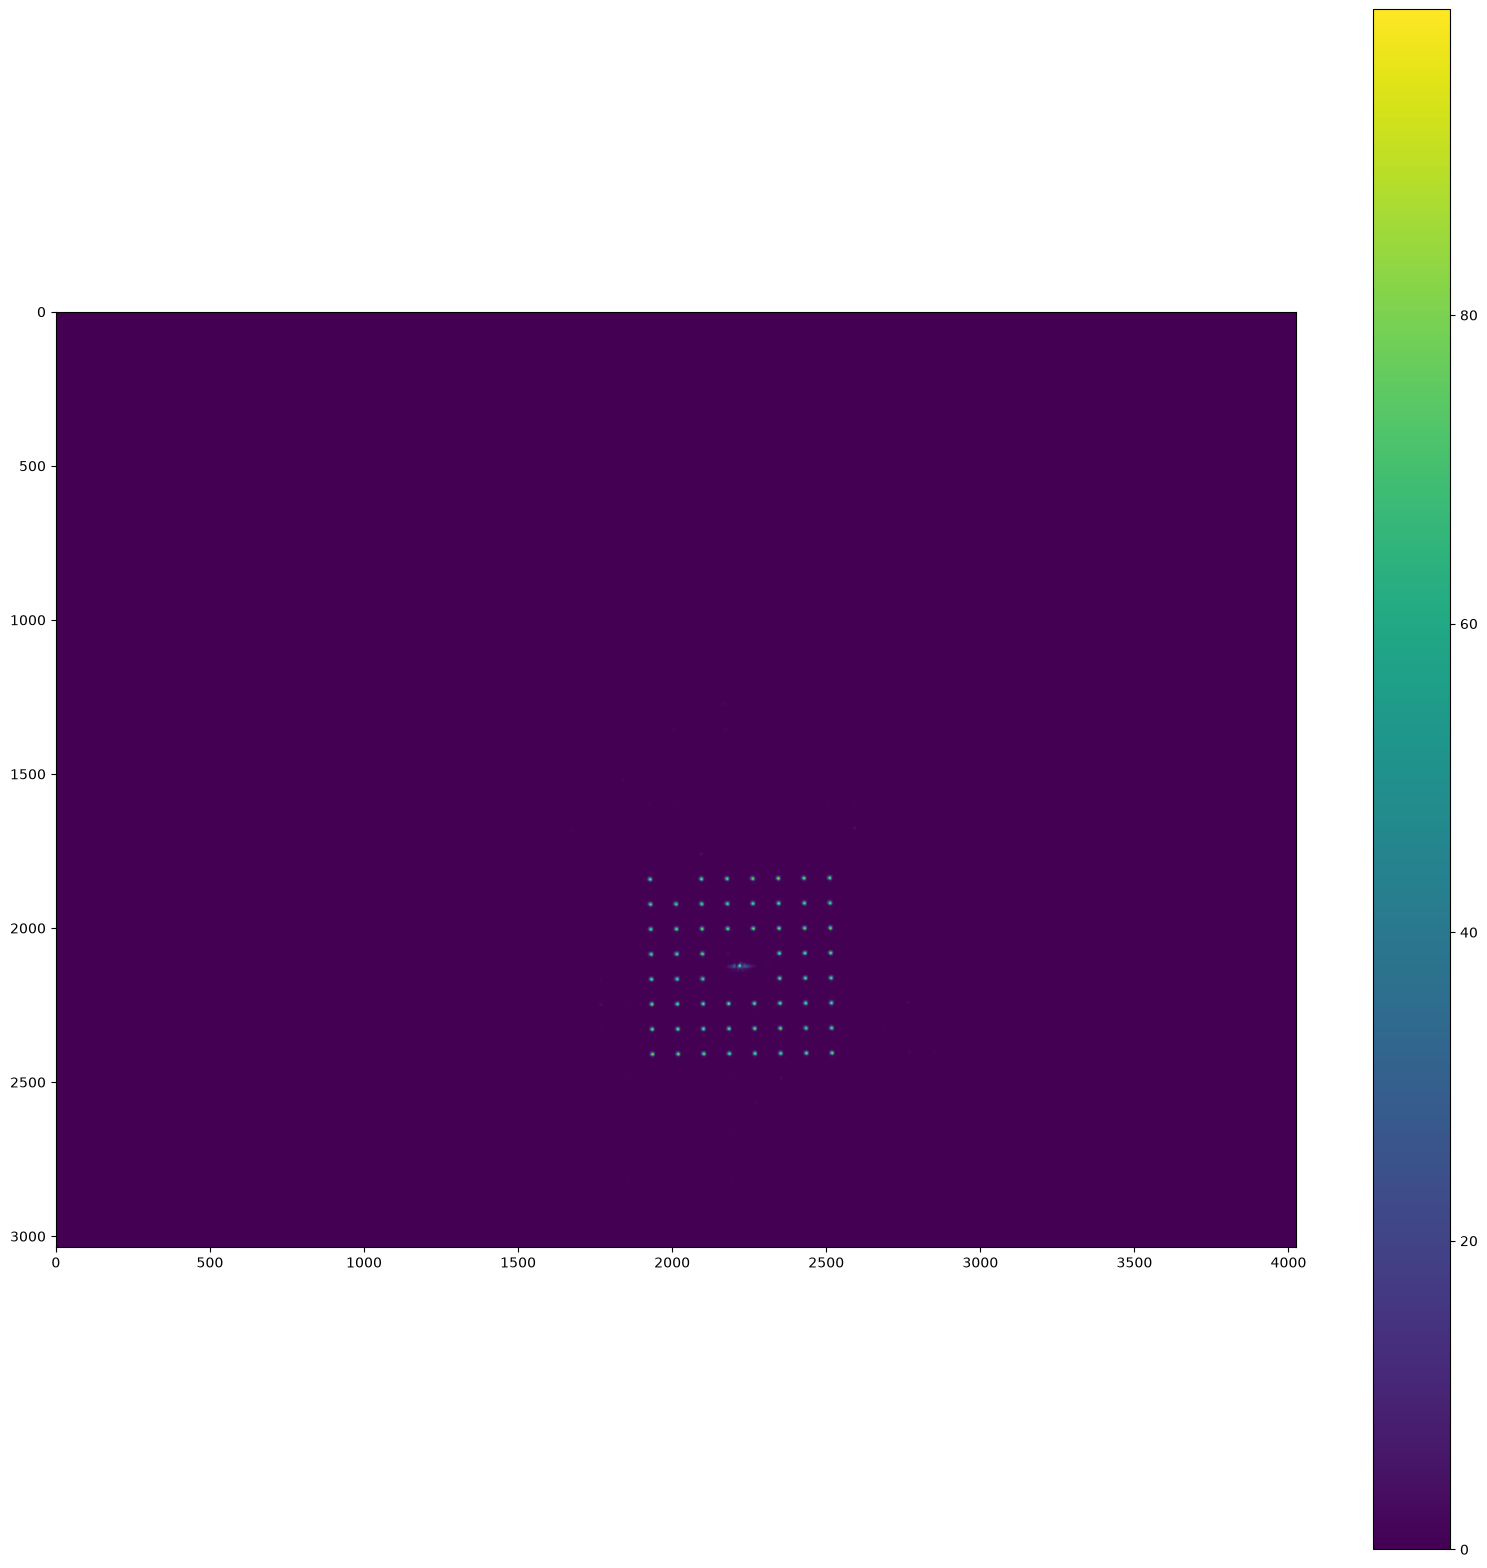

In [63]:
cam=VimbaCamera()
optimize = True
for index in range(1000):
    if index>6:
        optimize=False


    if optimize:

        SLM_screen_shift=SLM_screen+fresnel_lens
        SLM_screen_Corrected=SLM_screen_Correct(SLM_screen_shift)
        slm.updateArray(SLM_screen_Corrected)

    time.sleep(time_interval)

    image = [cam.capture(etime) for i in range(16)]
    image=np.array(image).mean(axis=0)
      
    cutted_image = image
    rotated_image_45=image
    image_ROI = []
    intensity = []
    for i  in range(len(x1)):
        cur_roi = rotated_image_45[x1[i]:x2[i],y1[i]:y2[i]]
        image_ROI.append(cur_roi)
        # popt, pcov, fitted_image = gaussian_2d_fit(image_ROI[i], show=False)
        # intensity.append(popt[0])
        intensity.append(image_ROI[i].sum())


    intensity = np.array(intensity)
    intensity_list.append(intensity)
    # non_uniformity.append(intensity.std()/intensity.mean())
    # camera_intensity = camera_intensity_array_generate(intensity)
    camera_intensity = intensity.copy()
    intensity_data.append(camera_intensity)
    non_uniformity.append(camera_intensity.std()/camera_intensity.mean())
    print(index,'标准差/均值：',camera_intensity.std()/camera_intensity.mean())

    # plt.hist(x = intensity, # 指定绘图数据
    #      bins = 20, # 指定直方图中条块的个数
    #      color = 'steelblue', # 指定直方图的填充色
    #      edgecolor = 'black' # 指定直方图的边框色
    #      )
    if index>0 and(index<10 or index%10==0):
        plt.plot(np.array(intensity_list)/intensity_list[0].mean())
        plt.show()

    if camera_intensity.std()/camera_intensity.mean()< 0.004:
        break


    if optimize:
        
        # camera_intensity_array = camera_intensity_array_generate(intensity)
        print('相机每个区域总光强:',intensity.mean(),'*',intensity/intensity.mean())
        camera_intensity_array = intensity.copy()
        cameraAmp = SLM.camera_Amp_generate(targetAmp, camera_intensity_array) 

        
        targetAmp = SLM.target_adapt(targetAmp, cameraAmp)
        targetAmp_array=targetAmp[np.nonzero(targetAmp)]
        cameraAmp_array=cameraAmp[np.nonzero(cameraAmp)]
        # print('调整后每个点振幅:',targetAmp_array.mean(),'*',targetAmp_array/targetAmp_array.mean())
        # sumAmp=np.multiply(targetAmp_array,cameraAmp_array)
        # print(sumAmp)


        targetAmp_data.append(targetAmp)

        print('Start the new SLM phase generation ...')

        SLM_Phase = WGS.WGS_phase_generate(torch.from_numpy(SLM.initGaussianAmp), SLM_Phase, torch.from_numpy(targetAmp), Loop=20, threshold=0.01)
        SLM_screen=SLM.phase_to_screen(SLM_Phase.cpu().clone().numpy())
        slm_screen_f_corrected = SLM_screen 
      
        # SLM.target_and_phase_save(targetAmp, SLM_Phase.cpu().clone().numpy(), slm_screen_f_corrected, info = "stagger",
        #                         adapt_times='-sum-'+str(index))
       
plt.figure()
non_uniformity_show(non_uniformity)

plt.figure(figsize=(20,20))
plt.imshow(image)
plt.colorbar()
plt.show()

cam.close()

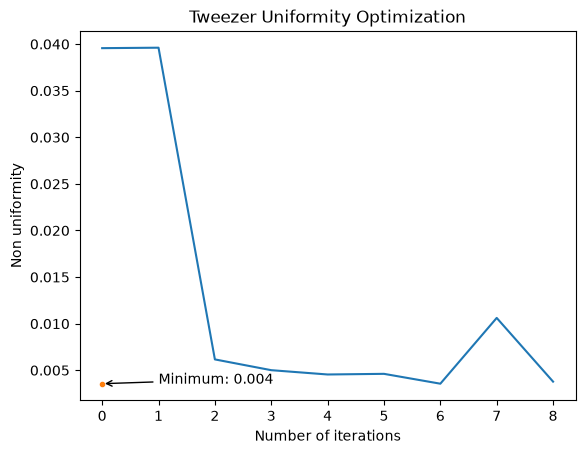

In [60]:
non_uniformity_show(non_uniformity[:730])


In [65]:
verify_cv = []
verify_intensity = []

cam = VimbaCamera()

try:
    for k in range(10):
        frames = [
            cam.capture(etime).astype(np.float32)
            for _ in range(16)
        ]

        verify_image = np.mean(frames, axis=0)

        intensity = []

        for i in range(len(x1)):
            roi = verify_image[
                x1[i]:x2[i],
                y1[i]:y2[i]
            ]

            intensity.append(roi.sum())

        intensity = np.asarray(intensity)

        cv = intensity.std() / intensity.mean()

        verify_intensity.append(intensity)
        verify_cv.append(cv)

        print(
            f"验证{k + 1}: "
            f"std/mean={cv:.6f} "
            f"= {cv * 100:.3f}%"
        )

        time.sleep(1)

finally:
    cam.close()

验证1: std/mean=0.012084 = 1.208%
验证2: std/mean=0.012388 = 1.239%
验证3: std/mean=0.012584 = 1.258%
验证4: std/mean=0.012289 = 1.229%
验证5: std/mean=0.012338 = 1.234%
验证6: std/mean=0.012038 = 1.204%
验证7: std/mean=0.046127 = 4.613%
验证8: std/mean=0.047257 = 4.726%
验证9: std/mean=0.014232 = 1.423%
验证10: std/mean=0.013828 = 1.383%


In [56]:
#保存
np.save("final_SLM_screen.npy", SLM_screen)

np.save(
    "final_SLM_phase.npy",
    SLM_Phase.detach().cpu().numpy()
)

np.save("final_targetAmp.npy", targetAmp)
np.save("final_intensity_history.npy", np.asarray(intensity_list))
np.save("final_non_uniformity.npy", np.asarray(non_uniformity))
np.save("verification_cv.npy", verify_cv)

print("最终优化结果已保存")
final_screen_shift = (
    (
        SLM_screen.astype(np.uint16)
        + fresnel_lens.astype(np.uint16)
    )
    % 256
).astype(np.uint8)

final_screen_corrected = SLM_screen_Correct(
    final_screen_shift
)

np.save(
    "final_SLM_screen_corrected.npy",
    final_screen_corrected
)

最终优化结果已保存


## slm gen center of array

In [ ]:

singleSLM = SLM_class()

singleSLM.image_init()
center_dis = (20+7*7.5, 0)
# center_dis = (80, 0)
input_shape = (4096, 4096) 
RandomPhase = torch.rand(input_shape, dtype=torch.float32) * 2 * np.pi - np.pi
singleAmp=singleSLM.target_generate(Lattice_type, distance=center_dis, arraysize=(1, 1),  Plot = True)

singleAmp_array=np.nonzero(singleAmp)


single_SLM_Phase=WGS.WGS_phase_generate(torch.tensor(initSLMAmp), torch.tensor(RandomPhase), torch.from_numpy(singleAmp), Loop=20, threshold=0.01, Plot=True)
single_SLM_screen=singleSLM.phase_to_screen(single_SLM_Phase.cpu().clone().numpy())


single_SLM_screen=singleSLM.phase_to_screen(single_SLM_Phase.cpu().clone().numpy())
single_fftAmp,single_fftPhase = singleSLM.phase_to_fftField(single_SLM_Phase.cpu())
plt.figure(figsize=(10,10))       

plt.imshow(single_fftAmp[1000:3000,1000:3000])
plt.show()


## apply center phase to slm

In [ ]:
blinkslm.slm_lib.Delete_SDK()
blinkslm=BlinkSLM()
# slm_phase=SLM.zernike_generate()
blinkslm.write_image((single_SLM_screen).astype('uint8'))

406 -607

In [ ]:

frame = []
# def setup_camera(cam: Camera):
#     with cam:
#         # Try to adjust GeV packet size. This Feature is only available for GigE - Cameras.
#         try:
            
#             cam.exposuretime=etime
#             print(cam.exposuretime)

#         except (AttributeError, VimbaFeatureError):
#             pass
#         try:
#             cam.GVSPAdjustPacketSize.run()

#             while not cam.GVSPAdjustPacketSize.is_done():
#                 pass

#         except (AttributeError, VimbaFeatureError):
#             pass

image = avt.get_image(64)
print(image.shape)

plt.figure(figsize=(20,10))
plt.imshow(image)
plt.colorbar()
plt.show()
print('max:',image.max())

## blink left right

### calculate phase

In [ ]:
center_dis = (20+7*7.5, 0)
upperSLM = SLM_class()

upperSLM.image_init()
upperAmp=upperSLM.target_generate(Lattice_type, distance=(20+7*7.5,50), arraysize=(1, 1),  Plot = True)


upperAmp_array=np.nonzero(upperAmp)


upper_SLM_Phase=WGS.WGS_phase_generate(torch.tensor(initSLMAmp), torch.tensor(RandomPhase), torch.from_numpy(upperAmp), Loop=2, threshold=0.01, Plot=True)
upper_SLM_screen=upperSLM.phase_to_screen(upper_SLM_Phase.cpu().clone().numpy())


upper_SLM_screen=upperSLM.phase_to_screen(upper_SLM_Phase.cpu().clone().numpy())
upper_fftAmp,upper_fftPhase = upperSLM.phase_to_fftField(upper_SLM_Phase.cpu())
plt.figure(figsize=(20,20))
plt.imshow(upper_fftAmp[1000:3000,1000:3000])
plt.show()

lowerSLM = SLM_class()

lowerSLM.image_init()
lowerAmp=lowerSLM.target_generate(Lattice_type, distance=(20+7*7.5, -50), arraysize=(1, 1),  Plot = True)


lowerAmp_array=np.nonzero(lowerAmp)


lower_SLM_Phase=WGS.WGS_phase_generate(torch.tensor(initSLMAmp), torch.tensor(RandomPhase), torch.from_numpy(lowerAmp), Loop=2, threshold=0.01, Plot=True)
lower_SLM_screen=lowerSLM.phase_to_screen(lower_SLM_Phase.cpu().clone().numpy())


lower_SLM_screen=lowerSLM.phase_to_screen(lower_SLM_Phase.cpu().clone().numpy())
lower_fftAmp,lower_fftPhase = lowerSLM.phase_to_fftField(lower_SLM_Phase.cpu())
plt.figure(figsize=(20,20))
plt.imshow(lower_fftAmp[1000:3000,1000:3000])
plt.show()

## apply to slm

In [ ]:
import time
print(upper_SLM_screen)
print(lower_SLM_screen)
while True:
    blinkslm.slm_lib.Delete_SDK()
    blinkslm=BlinkSLM()
    blinkslm.write_image((upper_SLM_screen).astype('uint8'))
    time.sleep(1)
    blinkslm.slm_lib.Delete_SDK()
    blinkslm=BlinkSLM()
    blinkslm.write_image((lower_SLM_screen).astype('uint8'))
    time.sleep(1)

voltex phase

In [ ]:
import time
N, M = (1024,1024)
xx, yy = np.meshgrid(np.arange(-M//2,M//2),np.arange(-N//2,N//2))
phase1 = np.arctan2(yy,xx)
phase1 = ((phase1 + np.pi)/(2*np.pi)*256).astype('uint8')

phase2 = np.arctan2(yy,xx)[::-1,::-1]
phase2 = ((phase1 + np.pi)/(2*np.pi)*256).astype("uint8")

phase = np.copy(phase1)
# phase[512-30:512+31,512-30:512+31] = phase2[512-30:512+31,512-30:512+31]

plt.imshow(phase)
plt.colorbar()
blinkslm.slm_lib.Delete_SDK()
blinkslm=BlinkSLM()
blinkslm.write_image(phase)


In [ ]:
import time
N, M = (1024,1024)
xx, yy = np.meshgrid(np.arange(-M//2,M//2),np.arange(-N//2,N//2))
zero_phase = np.zeros((N,M))

plt.imshow(zero_phase)
plt.colorbar()
blinkslm.slm_lib.Delete_SDK()
blinkslm=BlinkSLM()
blinkslm.write_image(zero_phase)


In [ ]:
blinkslm.slm_lib.Delete_SDK()


In [ ]:
blinkslm=BlinkSLM()
blinkslm.write_image((SLM_screen).astype('uint8'))